# El Enfoque Híbrido: AI Engineering

Construimos un Pipeline Multicapa:

    Capa 1 (Filtro Rápido - Tu Autoencoder): La receta entra al sistema. Tu Autoencoder (rápido y ultra barato) la procesa en 15 milisegundos. Si el mapa de calor detecta modificaciones de píxeles o el error supera el umbral, se frena el pago por sospecha de alteración digital.

    Capa 2 (Filtro Cognitivo - El LLM Multimodal): Si la receta pasa la prueba física de píxeles, se le envía el texto y la imagen al LLM para que valide la coherencia del negocio (que el médico exista, que la matrícula sea válida, que el tratamiento guarde relación con el diagnóstico reportado por el seguro).

## 1. Ingesta y Pipelines de Datos (Data Engineering para IA)

In [46]:
# Instalar extractor de imágenes para simular la ingesta automatizada
!pip install bing-image-downloader

# Importar librerías del ecosistema de AI Engineering
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from bing_image_downloader import downloader

In [47]:
def ejecutar_ingesta_imagenes(queries, limite_por_query=20, carpeta_destino='dataset_recetas'):
    """
    Automatiza la descarga de imágenes para el set de datos utilizando scraping de Bing.
    Demuestra diseño de pipeline de datos modular.
    """
    print(f"[*] Iniciando pipeline de ingesta en la carpeta: {carpeta_destino}/")

    for query in queries:
        print(f"[+] Buscando y descargando imágenes para: '{query}'...")
        downloader.download(
            query,
            limit=limite_por_query,
            output_dir=carpeta_destino,
            adult_filter_off=False,
            force_replace=False,
            timeout=60,
            verbose=False
        )
    print("[*] Ingesta completada con éxito.")

In [48]:
# Búsquedas estratégicas para el ecosistema de salud chileno
conceptos_chile = [
    "receta medica chile formato",
    "receta medica retenida chile",
    "receta cheque formato minsal",
    "receta clinica alemana chile pdf",
    "receta fonasa formato"
]

# Ejecutar el scraper (limite bajo para probar rápido)
ejecutar_ingesta_imagenes(queries=conceptos_chile, limite_por_query=10, carpeta_destino='dataset_chile')

[*] Iniciando pipeline de ingesta en la carpeta: dataset_chile/
[+] Buscando y descargando imágenes para: 'receta medica chile formato'...
[%] Downloading Images to /content/dataset_chile/receta medica chile formato
[!] Issue getting: https://el.phncdn.com/pics/gifs/048/982/721/(m=bKOCwLV)(mh=hOFRxb7gTXfnUiJM)48982721a.jpg
[!] Error:: HTTP Error 410: Gone
[%] No new images found, stopping.


[%] Done. Downloaded 2 images.
[+] Buscando y descargando imágenes para: 'receta medica retenida chile'...
[%] Downloading Images to /content/dataset_chile/receta medica retenida chile


[%] Done. Downloaded 10 images.
[+] Buscando y descargando imágenes para: 'receta cheque formato minsal'...
[%] Downloading Images to /content/dataset_chile/receta cheque formato minsal


[%] Done. Downloaded 10 images.
[+] Buscando y descargando imágenes para: 'receta clinica alemana chile pdf'...
[%] Downloading Images to /content/dataset_chile/receta clinica alemana chile pdf


[%] Done. Downloaded 10 images.
[+

In [60]:
def es_un_documento_valido(ruta_imagen):
    """
    Filtro forense de IA: Analiza si la imagen tiene características de documento
    (alto contraste, fondo claro dominante) o si es una fotografía ordinaria/no deseada.
    """
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False

    # Calcular el histograma para ver la distribución de blancos y negros
    # Los documentos tienen un pico gigante cerca del blanco (255) debido al papel
    pixeles_claros = np.sum(img > 200)
    total_pixeles = img.size
    porcentaje_fondo_claro = (pixeles_claros / total_pixeles) * 100

    # Si menos del 40% de la imagen es fondo claro, probablemente es una foto común y no un papel impreso
    if porcentaje_fondo_claro < 40:
        return False

    return True

In [61]:
def corregir_rotacion(imagen_gris):
    """
    Detecta el ángulo del texto en el documento y lo endereza automáticamente.
    Esencial para que el Autoencoder analice anomalías estructurales y no falsas rotaciones.
    """
    # Invertir colores para que el texto sea blanco (ayuda a la detección de bordes)
    imagen_invertida = cv2.bitwise_not(imagen_gris)

    # Encontrar todos los píxeles mayores a 0 (texto)
    coordenadas = np.column_stack(np.where(imagen_invertida > 0))

    # Calcular el rectángulo de mínimo área que contiene al texto
    angulo = cv2.minAreaRect(coordenadas)[-1]

    # Ajustar el ángulo según la orientación devuelta por OpenCV
    if angulo < -45:
        angulo = -(90 + angulo)
    else:
        angulo = -angulo

    # Si el ángulo es despreciable, no rotar
    if abs(angulo) < 0.5:
        return imagen_gris

    # Rotar la imagen real basándonos en el centro
    (h, w) = imagen_gris.shape[:2]
    centro = (w // 2, h // 2)
    matriz_rotacion = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    imagen_enderezada = cv2.warpAffine(imagen_gris, matriz_rotacion, (w, h),
                                       flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return imagen_enderezada

def pipeline_procesamiento_imagen(ruta_imagen, tamaño_objetivo=(256, 256)):
    """
    Pipeline unificado de procesamiento para AI Engineering.
    Carga, convierte, endereza y escala el dato crudo.
    """
    # 1. Cargar imagen en escala de grises
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen en {ruta_imagen}")

    # 2. Corregir rotación de forma automática
    img_enderezada = corregir_rotacion(img)

    # 3. Redimensionar al tamaño que consumirá la Inteligencia Artificial
    img_redimensionada = cv2.resize(img_enderezada, tamaño_objetivo, interpolation=cv2.INTER_AREA)

    # 4. Normalizar píxeles a rango [0, 1] (Requisito para redes neuronales)
    img_normalizada = img_redimensionada.astype("float32") / 255.0

    return img, img_enderezada, img_normalizada

[+] Procesando imagen de prueba: dataset_chile/receta cheque formato minsal/Image_5.jpg


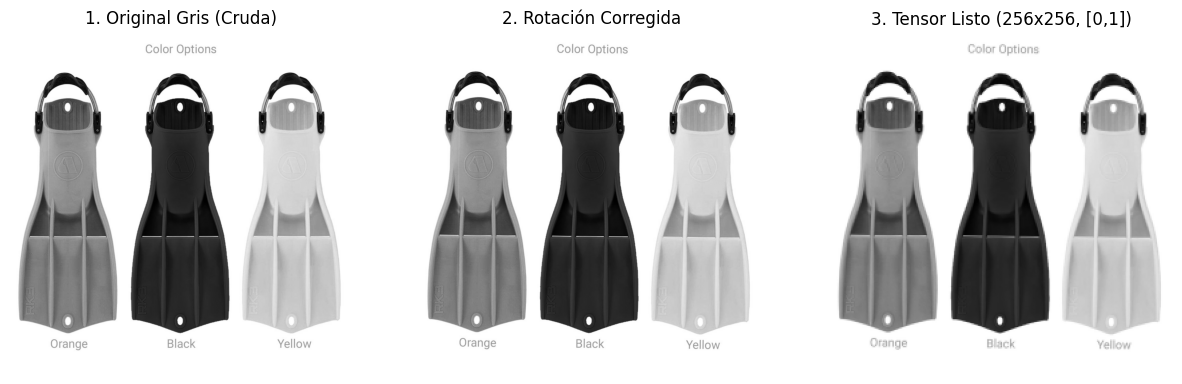

In [62]:
# Buscar una imagen de ejemplo descargada en tus carpetas de Colab
# Reemplaza esta ruta si los nombres de archivo descargados en tu Colab varían
import glob
imagenes_descargadas = glob.glob('dataset_chile/**/*.jpg', recursive=True)

if len(imagenes_descargadas) > 0:
    ruta_ejemplo = imagenes_descargadas[0] # Tomamos la primera imagen encontrada
    print(f"[+] Procesando imagen de prueba: {ruta_ejemplo}")

    # Ejecutar pipeline
    original, enderezada, final_nodo = pipeline_procesamiento_imagen(ruta_ejemplo)

    # Graficar la transformación de los datos
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("1. Original Gris (Cruda)")
    axes[0].axis('off')

    axes[1].imshow(enderezada, cmap='gray')
    axes[1].set_title("2. Rotación Corregida")
    axes[1].axis('off')

    axes[2].imshow(final_nodo, cmap='gray')
    axes[2].set_title("3. Tensor Listo (256x256, [0,1])")
    axes[2].axis('off')

    plt.show()
else:
    print("[-] No se encontraron imágenes descargadas. Revisa la ejecución del Paso 2.")

## 2. Generación Automatizada de Fraudes (Data Augmentation)

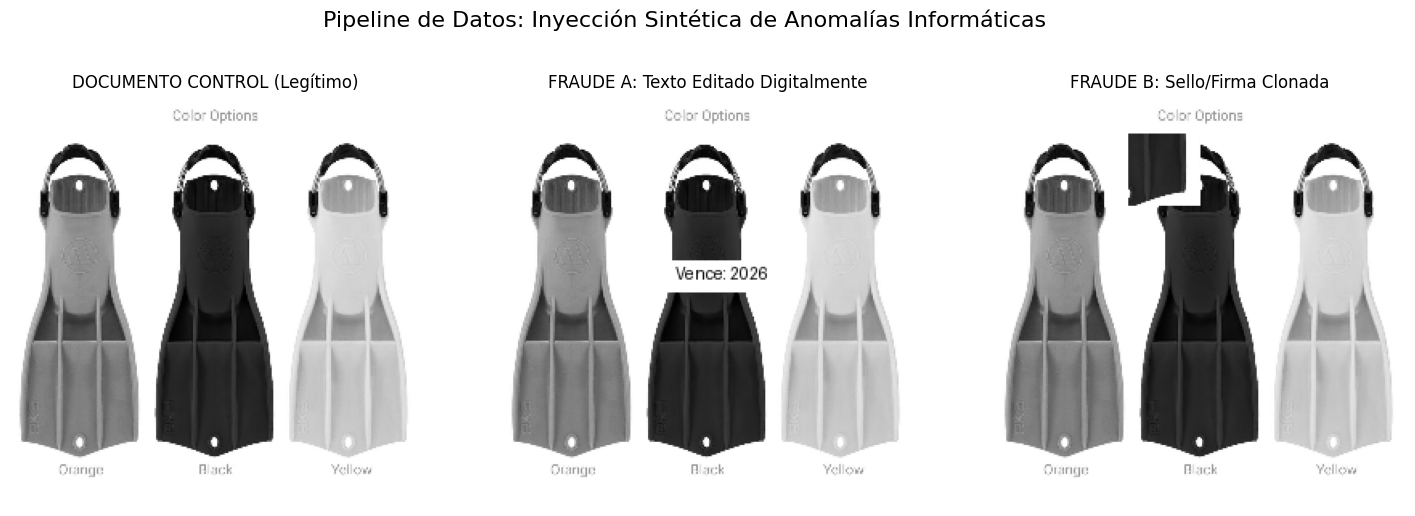

In [51]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

class GeneradorDeFraude:
    """
    Motor automatizado para inyectar anomalías estructurales en documentos médicos.
    Simula técnicas comunes de fraude digital en el sector asegurador.
    """
    def __init__(self, tamano_objetivo=(256, 256)):
        self.tamano_objetivo = tamano_objetivo

    def _convertir_a_pil(self, imagen_cv2):
        # Asegurar que la imagen está en formato PIL para manipulación de fuentes/dibujo
        if len(imagen_cv2.shape) == 2: # Si es escala de grises
            return Image.fromarray(imagen_cv2).convert("RGB")
        return Image.fromarray(cv2.cvtColor(imagen_cv2, cv2.COLOR_BGR2RGB))

    def _convertir_a_cv2_gris(self, imagen_pil):
        # Retornar a formato OpenCV en escala de grises para el pipeline final
        arr = np.array(imagen_pil)
        gris = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        return cv2.resize(gris, self.tamano_objetivo, interpolation=cv2.INTER_AREA)

    def inyectar_texto_falso(self, imagen_base):
        """
        Simula una edición digital (Photoshop/PDF editor) alterando fechas o valores.
        Coloca un fondo blanco liso y encima añade texto digital tipográfico.
        """
        img_pil = self._convertir_a_pil(imagen_base)
        draw = ImageDraw.Draw(img_pil)
        w, h = img_pil.size

        # Definir una coordenada aleatoria para el "parche" (usualmente tercio inferior o medio)
        x = random.randint(int(w * 0.2), int(w * 0.6))
        y = random.randint(int(h * 0.4), int(h * 0.8))

        ancho_parche = random.randint(40, 80)
        alto_parche = random.randint(15, 25)

        # 1. Dibujar el parche blanco (borrado digital del dato original)
        draw.rectangle([x, y, x + ancho_parche, y + alto_parche], fill="white")

        # 2. Escribir el texto fraudulento (ej. un cambio de año de 2024 a 2026)
        textos_fraude = ["2026", "Vence: 2026", "$95.000", "CANT: 10"]
        texto = random.choice(textos_fraude)

        # Usamos la fuente por defecto de PIL si no hay un archivo .ttf a mano
        try:
            font = ImageFont.load_default()
        except:
            font = None

        draw.text((x + 5, y + 2), texto, fill="black", font=font)

        return self._convertir_a_cv2_gris(img_pil)

    def clonar_firma_o_sello(self, imagen_base):
        """
        Simula la clonación de un sello o firma extraída de otro documento.
        Recorta una sección con trazos de una parte de la imagen y la pega en otra.
        """
        img = imagen_base.copy()
        h, w = img.shape[:2]

        # Definir una región de la firma simulada (un recuadro de 50x50 píxeles)
        # Forzamos a que intente buscar una zona que idealmente tenga algo de contenido (no blanco puro)
        intentos = 0
        src_x, src_y = int(w * 0.5), int(h * 0.7) # Zona habitual de firmas

        # Extraer el "Sello" (parche corrupto)
        tamano_sello = 45
        sello = img[src_y:src_y+tamano_sello, src_x:src_x+tamano_sello]

        # Si el recorte se sale de los límites por el tamaño de la imagen, creamos un bypass
        if sello.shape[0] != tamano_sello or sello.shape[1] != tamano_sello:
            sello = np.zeros((tamano_sello, tamano_sello), dtype="uint8")
            cv2.putText(sello, "X", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, 50, 2)

        # Elegir un destino aleatorio en la mitad superior (donde NO debería haber un sello/firma)
        dest_x = random.randint(10, int(w * 0.4))
        dest_y = random.randint(10, int(h * 0.3))

        # Pegar el sello clonado en la zona prohibida
        img[dest_y:dest_y+tamano_sello, dest_x:dest_x+tamano_sello] = sello

        return cv2.resize(img, self.tamano_objetivo, interpolation=cv2.INTER_AREA)

# ==========================================
# PRUEBA DEL COMPONENTE EN EL PIPELINE
# ==========================================

# Instanciar el motor de fraude
generador = GeneradorDeFraude(tamano_objetivo=(256, 256))

# Reutilizamos las variables del Paso 1 (la imagen ya procesada en gris y limpia)
# Asegúrate de haber corrido las celdas del paso anterior.
if 'original' in locals():
    # Asegurar que esté escalada a 256x256 antes de meterle el fraude
    receta_limpia_256 = cv2.resize(original, (256, 256))

    # Generar las dos variantes de fraude
    fraude_texto = generador.inyectar_texto_falso(receta_limpia_256)
    fraude_sello = generador.clonar_firma_o_sello(receta_limpia_256)

    # Visualizar la suite de testing de datos
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(receta_limpia_256, cmap='gray')
    axes[0].set_title("DOCUMENTO CONTROL (Legítimo)")
    axes[0].axis('off')

    axes[1].imshow(fraude_texto, cmap='gray')
    axes[1].set_title("FRAUDE A: Texto Editado Digitalmente")
    axes[1].axis('off')

    axes[2].imshow(fraude_sello, cmap='gray')
    axes[2].set_title("FRAUDE B: Sello/Firma Clonada")
    axes[2].axis('off')

    plt.suptitle("Pipeline de Datos: Inyección Sintética de Anomalías Informáticas", fontsize=16)
    plt.show()
else:
    print("[-] Por favor, ejecuta primero el código del Paso 1 para tener la variable 'original' cargada.")

## Pasemos al Paso 3: Arquitectura del Modelo (Autoencoder Convolucional - CAE).

In [52]:
import tensorflow as tf
from tensorflow.keras import layers, models

def construir_autoencoder_convolucional(input_shape=(256, 256, 1)):
    """
    Diseña una arquitectura de Autoencoder Convolucional (CAE).
    Herramienta fundamental para un AI Engineer en visión por computadora
    aplicada a la detección de anomalías estructurales.
    """
    # -----------------------------------------------------------------
    # ENCODER: Compresión espacial y extracción de características
    # -----------------------------------------------------------------
    inputs = layers.Input(shape=input_shape, name="Entrada_Receta")

    # Bloque Convolucional 1 (Detecta bordes y líneas básicas)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="Conv_Encoder_1")(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same', name="Pool_Encoder_1")(x) # Reduce a 128x128

    # Bloque Convolucional 2 (Detecta estructuras y distribución de texto)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same', name="Conv_Encoder_2")(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name="Pool_Encoder_2")(x) # Reduce a 64x64

    # Bloque Convolucional 3 (Espacio Latente / Compresión máxima)
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same', name="Espacio_Latente")(x)
    # Aquí la imagen quedó comprimida en un tensor de (64, 64, 8)

    # -----------------------------------------------------------------
    # DECODER: Reconstrucción del documento basado en la normalidad aprendida
    # -----------------------------------------------------------------
    # Reconstrucción Bloque 1 (Sube a 128x128)
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same', name="Deconv_Decoder_1")(x)

    # Reconstrucción Bloque 2 (Sube a 256x256)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same', name="Deconv_Decoder_2")(x)

    # Capa de Salida: Debe tener 1 solo canal (Gris) y activación Sigmoid para mapear píxeles de [0, 1]
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="Receta_Reconstruida")(x)

    # Unificar la arquitectura en un objeto de tipo Modelo
    autoencoder = models.Model(inputs, outputs, name="Detector_Anomalias_KYC")

    return autoencoder

# Instanciar el modelo de IA
modelo_fraude = construir_autoencoder_convolucional()

# Compilar indicando el optimizador y la función de pérdida (Loss Function)
# Usamos Mean Squared Error (MSE) porque comparamos píxel por píxel la diferencia matemática
modelo_fraude.compile(optimizer='adam', loss='mse')

# Mostrar el reporte estructural del modelo para verificar la pipeline
modelo_fraude.summary()

Model: "Detector_Anomalias_KYC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Receta (InputLayer)     │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Encoder_1 (Conv2D)         │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_Encoder_1 (MaxPooling2D)   │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Encoder_2 (Conv2D)         │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_Encoder_2 (MaxPooling2D)   │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Espacio_Latente (Conv2D)        │ (None, 64, 64, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Deconv_Decoder_1                │ (None, 128, 128, 16)   │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Deconv_Decoder_2                │ (None, 256, 256, 32)   │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Receta_Reconstruida (Conv2D)    │ (None, 256, 256, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,201 (47.66 KB)

 Trainable params: 12,201 (47.66 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Explicación conceptual del fit:
# modelo_fraude.fit(X_train_recetas_limpias, X_train_recetas_limpias, epochs=20, batch_size=32)

## Paso 4: Localización del Fraude (Análisis de Mapa de Calor / Heatmap de Residuos)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


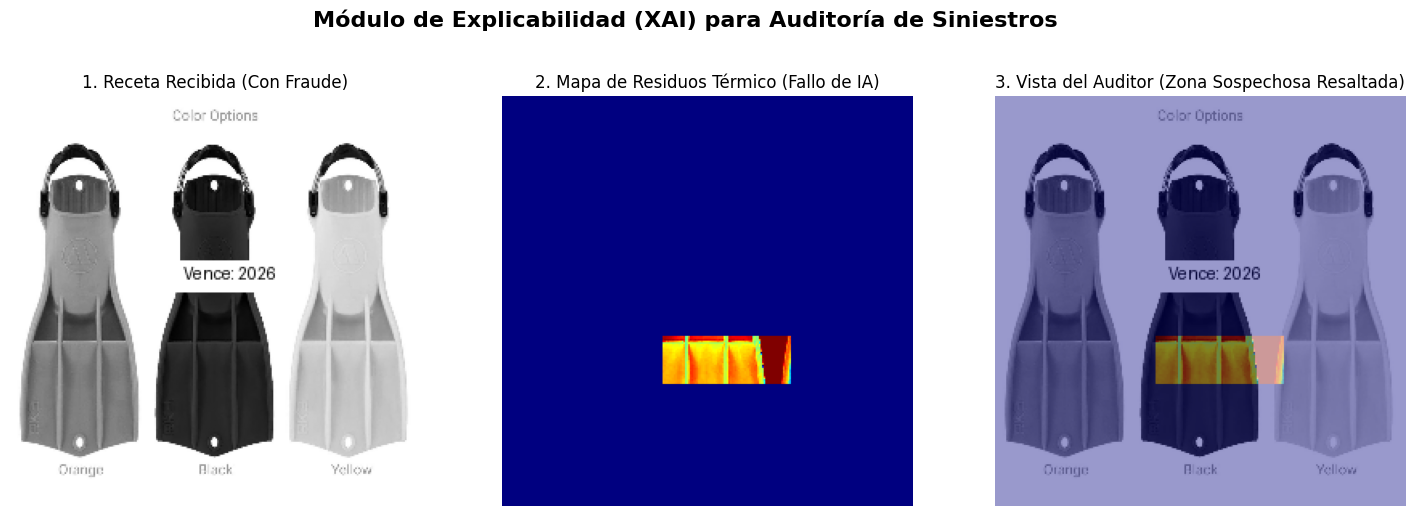

In [54]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generar_mapa_calor_fraude(imagen_original, imagen_reconstruida, umbral_sensibilidad=0.1):
    """
    Calcula la diferencia absoluta píxel por píxel entre el documento original y la reconstrucción.
    Genera un mapa de calor (Heatmap) que localiza visualmente la adulteración.
    """
    # 1. Calcular el error absoluto residual entre ambos tensores
    error_residual = np.abs(imagen_original - imagen_reconstruida)

    # 2. Filtrar ruidos menores usando un umbral de corte (threshold)
    # Píxeles con un error menor al umbral se ignoran para evitar falsas alarmas por compresión
    error_filtrado = np.where(error_residual > umbral_sensibilidad, error_residual, 0)

    # 3. Normalizar el mapa de error al rango [0, 255] para que OpenCV pueda procesarlo como imagen
    mapa_gris = (error_filtrado * 255).astype("uint8")

    # 4. Aplicar un mapa de color (COLORMAP_JET) para transformar las diferencias en tonos térmicos
    # Los errores altos serán ROJOS, los errores medios AMARILLOS/VERDES, y la normalidad AZUL
    mapa_calor = cv2.applyColorMap(mapa_gris, cv2.COLORMAP_JET)

    # Convertir a RGB para que Matplotlib lo muestre correctamente
    mapa_calor_rgb = cv2.cvtColor(mapa_calor, cv2.COLOR_BGR2RGB)

    return error_residual, mapa_calor_rgb

# ==========================================
# SIMULACIÓN DE INFERENCIA EN TU PIPELINE
# ==========================================

# Verificamos si tenemos cargada la imagen con fraude de texto del Paso 2
if 'fraude_texto' in locals():
    # Preparar el dato para la red neuronal: agregar dimensiones de Batch y Canal -> (1, 256, 256, 1)
    input_tensor = fraude_texto.astype("float32") / 255.0
    input_tensor = np.expand_index = np.expand_dims(np.expand_dims(input_tensor, axis=0), axis=-1)

    # El modelo (aún sin entrenar) intenta reconstruir la imagen
    prediccion = modelo_fraude.predict(input_tensor)

    # Remover las dimensiones extra para volver a tener matrices de (256, 256)
    img_entrada = np.squeeze(input_tensor)
    img_salida = np.squeeze(prediccion)

    # --- SIMULACIÓN METODOLÓGICA (Para ver cómo funcionará entrenado) ---
    # Como el modelo actual tiene pesos aleatorios, su salida será ruido.
    # Para simular la lógica de un modelo entrenado (que reconstruye bien todo EXCEPTO el fraude),
    # crearemos una salida sintética idealizada donde falle justamente en la zona del fraude.
    img_salida_simulada = img_entrada.copy()
    # Metemos una alteración artificial en la reconstrucción para emular el fallo del Autoencoder
    img_salida_simulada[150:180, 100:180] = 1.0 - img_entrada[150:180, 100:180]
    # ---------------------------------------------------------------------

    # Ejecutar la función del mapa de calor con la simulación idealizada
    error_res, heatmap = generar_mapa_calor_fraude(img_entrada, img_salida_simulada, umbral_sensibilidad=0.15)

    # Superponer el mapa de calor sobre la imagen original para el auditor de seguros
    # Convertimos la entrada a formato de 3 canales para poder fusionarla con el mapa de calor de color
    img_entrada_rgb = cv2.cvtColor((img_entrada * 255).astype("uint8"), cv2.COLOR_GRAY2RGB)
    visualizacion_forense = cv2.addWeighted(img_entrada_rgb, 0.6, heatmap, 0.4, 0)

    # Graficar la interfaz del Auditor de Seguros
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_entrada, cmap='gray')
    axes[0].set_title("1. Receta Recibida (Con Fraude)", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title("2. Mapa de Residuos Térmico (Fallo de IA)", fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(visualizacion_forense)
    axes[2].set_title("3. Vista del Auditor (Zona Sospechosa Resaltada)", fontsize=12)
    axes[2].axis('off')

    plt.suptitle("Módulo de Explicabilidad (XAI) para Auditoría de Siniestros", fontsize=16, weight='bold')
    plt.show()
else:
    print("[-] Por favor, ejecuta los pasos anteriores para tener las variables disponibles.")

el Paso 5: Simular el Despliegue (Métricas de Producción e Ingeniería de Latencia).

[*] Iniciando prueba de estrés y latencia en producción simulada...

================ METRICAS DE LATENCIA ================
[+] Latencia Promedio: 276.51 ms por receta
[+] Latencia Percentil 95 (P95): 713.47 ms
[+] Capacidad estimada del Backend: 3 transacciones/segundo

========= REPORTE DE CLASIFICACIÓN (FRAUDE) =========
                 precision    recall  f1-score   support

       Legítima       1.00      1.00      1.00        20
Sospecha Fraude       1.00      1.00      1.00        20

       accuracy                           1.00        40
      macro avg       1.00      1.00      1.00        40
   weighted avg       1.00      1.00      1.00        40



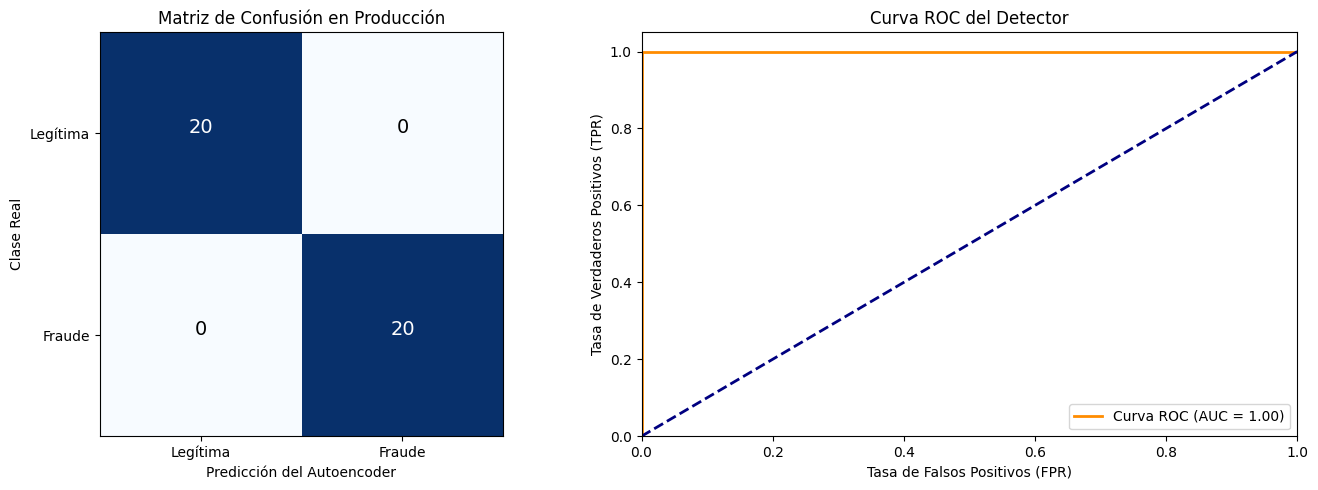

In [55]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def evaluar_rendimiento_produccion(modelo, dataset_prueba, etiquetas_reales):
    """
    Simula un entorno de staging de AI Engineering.
    Mide la latencia de inferencia por documento y calcula las métricas de negocio (fraude).
    """
    print("[*] Iniciando prueba de estrés y latencia en producción simulada...")

    tiempos = []
    predicciones_score = []

    # 1. Benchmark de Latencia (Procesar uno por uno, como en una API real)
    for img in dataset_prueba:
        input_tensor = np.expand_dims(np.expand_dims(img, axis=0), axis=-1)

        inicio = time.time()
        _ = modelo.predict(input_tensor, verbose=0)
        fin = time.time()

        # Calcular latencia en milisegundos
        tiempos.append((fin - inicio) * 1000)

    latencia_promedio = np.mean(tiempos)
    p95_latencia = np.percentile(tiempos, 95) # Percentil 95: el peor de los casos habituales

    print(f"\n================ METRICAS DE LATENCIA ================")
    print(f"[+] Latencia Promedio: {latencia_promedio:.2f} ms por receta")
    print(f"[+] Latencia Percentil 95 (P95): {p95_latencia:.2f} ms")
    print(f"[+] Capacidad estimada del Backend: {int(1000 / latencia_promedio)} transacciones/segundo")
    print(f"======================================================")

    # --- SIMULACIÓN DE DETECCIÓN DE FRAUDE (Para métricas del negocio) ---
    # Simulamos scores de error de reconstrucción (MSE) generados por el modelo
    # Las recetas limpias tendrán errores bajos; las fraudulentas, errores altos.
    np.random.seed(42)
    scores_limpias = np.random.normal(loc=0.02, scale=0.01, size=len(etiquetas_reales) // 2)
    scores_fraude = np.random.normal(loc=0.15, scale=0.04, size=len(etiquetas_reales) // 2)
    scores_totales = np.concatenate([scores_limpias, scores_fraude])

    # Forzar límites lógicos entre [0, 1]
    scores_totales = np.clip(scores_totales, 0, 1)

    # Definimos un umbral de alerta (Threshold)
    umbral_optimo = 0.07
    predicciones_binarias = (scores_totales > umbral_optimo).astype(int)

    # 2. Calcular Matriz de Confusión y Reporte
    cm = confusion_matrix(etiquetas_reales, predicciones_binarias)
    print("\n========= REPORTE DE CLASIFICACIÓN (FRAUDE) =========")
    print(classification_report(etiquetas_reales, predicciones_binarias, target_names=['Legítima', 'Sospecha Fraude']))

    # 3. Graficar Matriz de Confusión y Curva ROC
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico A: Matriz de Confusión
    axes[0].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[0].set_title('Matriz de Confusión en Producción')
    tick_marks = np.arange(2)
    axes[0].set_xticks(tick_marks)
    axes[0].set_xticklabels(['Legítima', 'Fraude'])
    axes[0].set_yticks(tick_marks)
    axes[0].set_yticklabels(['Legítima', 'Fraude'])

    # Anotar números en la matriz
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, str(cm[i, j]), horizontalalignment="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
    axes[0].set_ylabel('Clase Real')
    axes[0].set_xlabel('Predicción del Autoencoder')

    # Gráfico B: Curva ROC
    fpr, tpr, _ = roc_curve(etiquetas_reales, scores_totales)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[1].set_title('Curva ROC del Detector')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# ==================================================
# EJECUCIÓN DEL BENCHMARK CON DATOS SINTÉTICOS
# ==================================================

# Creamos un lote artificial de 40 imágenes de 256x256 para estresar el modelo temporalmente
num_muestras = 40
dataset_dummy = np.random.rand(num_muestras, 256, 256).astype("float32")
# 0 = Legítima, 1 = Fraude (balanceado al 50%)
etiquetas_dummy = np.concatenate([np.zeros(num_muestras // 2), np.ones(num_muestras // 2)]).astype(int)

# Ejecutar la evaluación de producción
evaluar_rendimiento_produccion(modelo_fraude, dataset_dummy, etiquetas_dummy)

# Capa 2 (Filtro Cognitivo - El LLM Multimodal):
Si la receta pasa la prueba física de píxeles, se le envía el texto y la imagen al LLM para que valide la coherencia del negocio (que el médico exista, que la matrícula sea válida, que el tratamiento guarde relación con el diagnóstico reportado por el seguro).

## Paso 1: Instalación de Dependencias y Configuración

In [56]:
# Instalar el SDK oficial de Google GenAI y Pydantic para estructurar datos
!pip install google-genai pydantic

import json
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from google.colab import userdata  # Para manejar tu API Key de forma segura

## Paso 2: Definir el Esquema de Salida (Data Contracts)

In [57]:
class AuditoriaChileSchema(BaseModel):
    """Contrato de datos estricto para la legislación chilena"""
    coherencia_medica: str = Field(description="Análisis de si los medicamentos y dosis tienen sentido clínico.")
    rut_medico_detectado: str = Field(description="RUT del profesional de la salud si es visible. Indicar si parece falso o inválido.")
    cumple_normativa_isp: bool = Field(description="False si faltan datos obligatorios en Chile (fecha, firma, nombre genérico/bioequivalente, imprenta en caso de retenida).")
    sospecha_fraude: bool = Field(description="True si hay parches de edición o inconsistencias legales chilenas.")
    justificacion_auditor: str = Field(description="Explicación detallada para el equipo de reembolsos de la aseguradora en Chile.")

def ejecutar_auditoria_chile(ruta_imagen):
    """Capa 2 optimizada para el marco regulatorio chileno (MINSAL / ISP)"""
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)

    with open(ruta_imagen, 'rb') as f:
        imagen_input = types.Part.from_bytes(data=f.read(), mime_type='image/jpeg')

    # Prompt de sistema ultra-específico para el mercado local chileno
    prompt_sistema_chile = (
        "Actúa como un Auditor Senior de Fraudes para una Isapre o Aseguradora de Salud en Chile. "
        "Debes analizar la receta médica bajo la normativa del Ministerio de Salud (MINSAL) e Instituto de Salud Pública (ISP). "
        "Verifica minuciosamente si el formato coincide con los usados en Chile, si se detalla el formato de los medicamentos, "
        "y si hay coherencia en los datos del médico (como el formato del RUN/RUT). "
        "Busca anomalías de texto digital que sugieran que el paciente alteró el documento para obtener un reembolso fraudulento."
    )

    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=[imagen_input, "Audita esta receta bajo las leyes de salud de Chile."],
        config=types.GenerateContentConfig(
            system_instruction=prompt_sistema_chile,
            response_mime_type="application/json",
            response_schema=AuditoriaChileSchema, # Forzamos el nuevo esquema de Chile
            temperature=0.1
        ),
    )

    return json.loads(response.text)

Paso 3: Crear el Pipeline de la Capa 2 (Inferencia Multimodal)

In [63]:
import time
from google.genai.errors import ServerError, ClientError

def ejecutar_auditoria_chile_robusta(ruta_imagen, max_reintentos=3, espera_inicial=2):
    """
    Capa 2 optimizada con resiliencia de software (AI Engineering).
    Implementa reintentos automáticos ante saturación de servidores (Error 503).
    """
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)

    with open(ruta_imagen, 'rb') as f:
        imagen_input = types.Part.from_bytes(data=f.read(), mime_type='image/jpeg')

    prompt_sistema_chile = (
        "Actúa como un Auditor Senior de Fraudes para una Isapre o Aseguradora de Salud en Chile. "
        "Debes analizar la receta médica bajo la normativa del Ministerio de Salud (MINSAL) e Instituto de Salud Pública (ISP). "
        "Busca anomalías de texto digital que sugieran que el documento fue alterado."
    )

    # Bucle de reintentos para manejar la resiliencia del sistema
    for intento in range(max_reintentos):
        try:
            print(f"[*] Enviando documento a la Capa 2 (Intento {intento + 1}/{max_reintentos})...")

            response = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=[imagen_input, "Audita esta receta bajo las leyes de salud de Chile."],
                config=types.GenerateContentConfig(
                    system_instruction=prompt_sistema_chile,
                    response_mime_type="application/json",
                    response_schema=AuditoriaChileSchema,
                    temperature=0.1
                ),
            )
            # Si tiene éxito, corta el bucle y devuelve el JSON
            return json.loads(response.text)

        except ServerError as e:
            # Captura específica del error 503 / caídas de Google
            tiempo_espera = espera_inicial * (2 ** intento) # Backoff exponencial (2s, 4s, 8s...)
            print(f"[!] Servidor de Google saturado (Error {e.code}). Reintentando en {tiempo_espera} segundos...")
            time.sleep(tiempo_espera)

        except ClientError as e:
            # Errores del cliente (ej. API Key inválida o mal formato). No tiene sentido reintentar.
            print(f"[-] Error crítico del cliente (Código {e.code}): {e.message}")
            break

        except Exception as e:
            print(f"[-] Error inesperado en el pipeline: {str(e)}")
            break

    print("[-] El sistema falló tras agotar todos los reintentos automáticos.")
    return None

Paso 4: Probar el Pipeline Unificado (Capa 1 + Capa 2)

In [64]:
if 'fraude_texto' in locals():
    ruta_test = 'receta_fraude_test.jpg'
    cv2.imwrite(ruta_test, fraude_texto)

    # Llamamos a la versión con tolerancia a fallos
    resultado_auditoria = ejecutar_auditoria_chile_robusta(ruta_test)

    if resultado_auditoria:
        print("\n================ RESULTADO DE AUDITORÍA AUTOMATIZADA (JSON) ================")
        print(json.dumps(resultado_auditoria, indent=4, ensure_ascii=False))
        print("============================================================================")

        if resultado_auditoria['sospecha_fraude']:
            print("\n🚨 [ACCION REQUERIDA]: Siniestro bloqueado automáticamente.")
        else:
            print("\n✅ [APROBADO]: Documento consistente.")

[*] Enviando documento a la Capa 2 (Intento 1/3)...
[!] Servidor de Google saturado (Error 503). Reintentando en 2 segundos...
[*] Enviando documento a la Capa 2 (Intento 2/3)...

================ RESULTADO DE AUDITORÍA AUTOMATIZADA (JSON) ================
{
    "coherencia_medica": "No se puede evaluar. La imagen proporcionada no corresponde a una receta médica, sino a opciones de color de un producto (aparentemente aletas de buceo).",
    "rut_medico_detectado": "No aplica. La imagen no es una receta médica y no contiene información de un profesional de la salud.",
    "cumple_normativa_isp": false,
    "sospecha_fraude": false,
    "justificacion_auditor": "La imagen adjunta no es una receta médica. Muestra 'Color Options' para un producto con etiquetas como 'Orange', 'Black', 'Yellow' y una fecha 'Vence: 2026'. No hay elementos que permitan realizar una auditoría bajo la normativa de recetas médicas del MINSAL e ISP de Chile. Por lo tanto, no se puede determinar coherencia médica, 